In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Grover's Search algorithm
* **Input**: $f:\{0,1\}^n\to\{0,1\}$ such that it has a set of inputs $A_1$ at which $f(x) = 1$
* **Promise**: $$f(x)=\begin{cases}1& x \in A_1\\ 0& x\notin A_1\end{cases}$$
* **Task**: Find any $x_0\in A_1$

## Oracle
* The generic oracle $U_f$ acts as $|x\rangle|y\rangle\to |x\rangle|y\oplus f(x)\rangle$
* with $|y\rangle$ replaced by eigenvector $|-\rangle$, we can write $$|x\rangle|-\rangle\to (-1)^{f(x)}|x\rangle|-\rangle$$

## Reflection
* Consider the uniform state $|\alpha\rangle = \frac{1}{\sqrt{2^n}}\sum_x |x\rangle$
* Projector along $|\alpha\rangle$ is $|\alpha\rangle\langle\alpha|$
* A reflector about $|\alpha\rangle$ will be given by $$R = 2|\alpha\rangle\langle\alpha|-I = H^{\otimes n}(2\outpro{0}{0} -I)H^{\otimes n}$$

## Initial State
* Let $|A_1| = M$.
* We can define $$\begin{align}|A_0\rangle &= \frac{1}{\sqrt{N-M}}\sum_{x\notin A_1}|x\rangle\\ |A_1\rangle &= \frac{1}{\sqrt{M}}\sum_{x\in A_1}|x\rangle\end{align}$$
* Notice that $|A_0\rangle$ and $A_1\rangle$ are orthonormal and $$|\alpha\rangle = \sqrt{\frac{N-M}{N}}|A_0\rangle + \sqrt{\frac{M}{N}}|A_1\rangle$$
* Define $\theta$ as $$\cos\frac{\theta}{2} = \sqrt{\frac{N-M}{M}}$$
  we can write the initial state as $$|\alpha\rangle = \cos\frac{\theta}{2}|A_0\rangle + \sin\frac{\theta}{2}|A_1\rangle= \begin{bmatrix}\cos\frac{\theta}{2}\\ \sin\frac{\theta}{2}\end{bmatrix}$$
## Operations in new 2-dimensional basis
* Action of $U_f$: $$U_f|\alpha\rangle|-\rangle = U_f(\cos\frac{\theta}{2}|A_0\rangle + \sin\frac{\theta}{2}|A_1\rangle)|-\rangle = (\cos\frac{\theta}{2}|A_0\rangle - \sin\frac{\theta}{2}|A_1\rangle)|-\rangle$$ That is, it reflects about $|A_0\rangle$
$$U_f = \begin{bmatrix}1 & 0\\ 0& -1\end{bmatrix} = Z$$
* The reflection $R$ now can be written as 
$$\begin{align}
    R &= 2|\alpha\rangle\langle\alpha| - I\\
    &= 2(\cos\frac{\theta}{2}|A_0\rangle + \sin\frac{\theta}{2}|A_1\rangle)(\cos\frac{\theta}{2}\langle A_0| + \sin\frac{\theta}{2}\langle A_1|) - I\\
    &= 2\cos^2\frac{\theta}{2}|A_0\rangle\langle A_0| + 2\sin^2\frac{\theta}{2}|A_1\rangle\langle A_1| + 2\sin\frac{\theta}{2}\cos\frac{\theta}{2}|A_1\rangle\langle A_0| + 2\sin\frac{\theta}{2}\cos\frac{\theta}{2}|A_0\rangle\langle A_1| - (|A_0\rangle\langle A_0| + |A_1\rangle\langle A_1|)\\
    &= \cos\theta|A_0\rangle\langle A_0| - \cos\theta|A_1\rangle\langle A_1| + \sin\theta |A_1\rangle\langle A_0| + \sin\theta |A_0\rangle\langle A_1|  
\end{align}$$
* Therefore, in basis defined by $|A_0\rangle$ and $|A_1\rangle$, we can write 
        $$R=\begin{bmatrix}\cos\theta & \sin\theta\\ \sin\theta & -\cos\theta\end{bmatrix}$$
* Action of $R$: 
$$\begin{align}
    R(\cos\phi|A_0\rangle + \sin\phi|A_1\rangle) &= \begin{bmatrix}\cos\theta & \sin\theta\\ \sin\theta & -\cos\theta\end{bmatrix}\begin{bmatrix}\cos\phi\\ \sin\phi\end{bmatrix} = \begin{bmatrix}\cos(\theta-\phi)\\ \sin(\theta-\phi)\end{bmatrix} 
\end{align}$$

## Grover's operator
* We combine the oracle $U_f$ and reflector $R$, we define Grover operator $$G = RU_f$$.
* In $|A_0\rangle, |A_1\rangle$ basis this becomes rotation by angle $\theta$
$$\begin{align}
    G &= \begin{bmatrix}\cos\theta & \sin\theta\\ \sin\theta & -\cos\theta\end{bmatrix}\begin{bmatrix}1 & 0\\ 0& -1\end{bmatrix}\\
    &= \begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}
\end{align}$$
* $k$ applications of $G$ is $$G^k=\begin{bmatrix}\cos k\theta & -\sin k\theta\\ \sin k\theta & \cos k\theta\end{bmatrix}$$
* The state after $k$ Grover operations is 
$$G^k |\phi\rangle=\begin{bmatrix}\cos k\theta & -\sin k\theta\\ \sin k\theta & \cos k\theta\end{bmatrix}\begin{bmatrix}\cos\phi\\ \sin\phi\end{bmatrix} = \begin{bmatrix}\cos(k\theta+\phi)\\ \sin(k\theta+\phi)\end{bmatrix}$$
* As $\phi = \frac{\theta}{2}$, the final state would be $$G^k|\alpha\rangle = \begin{bmatrix}\cos\frac{2k + 1}{2}\theta\\ \sin\frac{2k + 1}{2}\theta\end{bmatrix}$$
* We want the final state to be along $|A_1\rangle$, i.e. $\cos\frac{2k + 1}{2}\theta = 0$. This implies $$\frac{2k + 1}{2}\theta = \frac{\pi}{2}\implies k \sim \lceil\frac{\pi}{2\theta}-\frac{1}{2}\rfloor$$
* We know that $$\sin\frac{\theta}{2} = \sqrt{\frac{M}{N}}$$ 
* For small $M$, $\theta$ will be small. 
                $$\begin{align}
                \frac{\theta}{2} \geq \sin\frac{\theta}{2} = \sqrt{\frac{M}{N}}\\
                \implies \theta \geq 2\sqrt{\frac{M}{N}}\\
                \implies k \sim \lceil\frac{\pi}{4}\sqrt{\frac{N}{M}}-\frac{1}{2}\rfloor
                \end{align}$$
* It is important to note that we may not know $M$. This creates ambiguity in when to stop applying Grover's operator.

In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMT, ZGate
from qiskit_algorithms import Grover
from qiskit.primitives import StatevectorSampler as Sampler
from math import pi

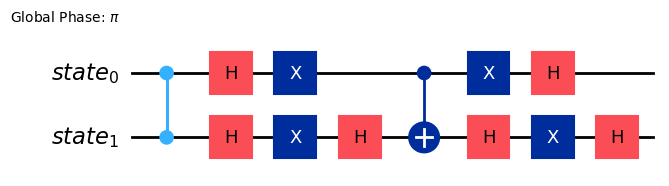

In [5]:
from qiskit import QuantumCircuit
from qiskit_algorithms import AmplificationProblem

# the state we desire to find is '11'
good_state = ["11"]

# specify the oracle that marks the state '11' as a good solution
oracle = QuantumCircuit(2)
oracle.cz(0, 1)

# define Grover's algorithm
problem = AmplificationProblem(oracle, is_good_state=good_state)

# now we can have a look at the Grover operator that is used in running the algorithm
# (Algorithm circuits are wrapped in a gate to appear in composition as a block
# so we have to decompose() the op to see it expanded into its component gates.)
problem.grover_operator.decompose().draw(output="mpl")

In [10]:
from qiskit.quantum_info import Operator

# 1. Extract the Grover operator from the problem
# We use decompose() to ensure we are looking at the gate level
grover_op = problem.grover_operator.decompose()

# 2. Convert it to a matrix
matrix = Operator(grover_op).data

# 3. Print it nicely (rounding to handle small floating point errors)
import numpy as np
print(Operator(oracle).data)
print(np.round(matrix, 3))

[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]
[[-0.5+0.j  0.5-0.j  0.5-0.j -0.5+0.j]
 [ 0.5-0.j -0.5+0.j  0.5-0.j -0.5+0.j]
 [ 0.5-0.j  0.5-0.j -0.5+0.j -0.5+0.j]
 [ 0.5-0.j  0.5-0.j  0.5-0.j  0.5-0.j]]


In [10]:
from qiskit_algorithms import Grover
from qiskit.primitives import StatevectorSampler


grover = Grover(sampler=StatevectorSampler())
result = grover.amplify(problem)
print("Result type:", type(result))
print()
print("Success!" if result.oracle_evaluation else "Failure!")
print("Top measurement:", result.top_measurement)

Result type: <class 'qiskit_algorithms.amplitude_amplifiers.grover.GroverResult'>

Success!
Top measurement: 11


### Using the different types of classes as the oracle of Grover
In the above example, we used QuantumCircuit as the oracle of Grover. However, we can also use qiskit.quantum_info.Statevector as oracle. All the following examples are when 
$|11\rangle$ is “good state”

In [11]:
from qiskit.quantum_info import Statevector

oracle = Statevector.from_label("11")
problem = AmplificationProblem(oracle, is_good_state=["11"])

grover = Grover(sampler=StatevectorSampler())
result = grover.amplify(problem)
print("Result type:", type(result))
print()
print("Success!" if result.oracle_evaluation else "Failure!")
print("Top measurement:", result.top_measurement)

Result type: <class 'qiskit_algorithms.amplitude_amplifiers.grover.GroverResult'>

Success!
Top measurement: 11


Internally, the statevector is mapped to a quantum circuit:

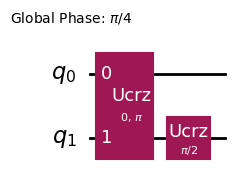

In [12]:
problem.grover_operator.oracle.decompose().draw(output="mpl")

* Qiskit allows for an easy construction of more complex oracles:
* `PhaseOracle`: for parsing logical expressions such as '~a | b'. This is especially useful for solving 3-SAT problems.
* Here we’ll use the `PhaseOracleGate` for the simple example of finding the state $|11\rangle$, which corresponds to 'a & b'.

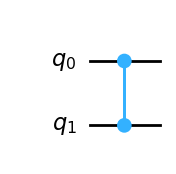

In [13]:
from qiskit.circuit.library.phase_oracle import PhaseOracleGate
from qiskit.exceptions import MissingOptionalLibraryError

# `Oracle` (`PhaseOracleGate`) as the `oracle` argument
expression = "(a & b)"
try:
    oracle = PhaseOracleGate(expression)
    problem = AmplificationProblem(oracle)
    display(problem.grover_operator.oracle.decompose().draw(output="mpl"))
except MissingOptionalLibraryError as ex:
    print(ex)

# Amplitude Amplification
## State preparation

Oracle


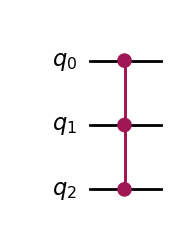

State prepared


<IPython.core.display.Latex object>

state preparation circuit:


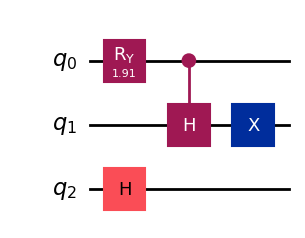

In [18]:
import numpy as np

# Specifying `state_preparation`
# to prepare a superposition of |01>, |10>, and |11>
oracle = QuantumCircuit(3)
oracle.ccz(0, 1, 2)
print("Oracle")
display(oracle.draw("mpl"))
theta = 2 * np.arccos(1 / np.sqrt(3))
state_preparation = QuantumCircuit(3)
state_preparation.ry(theta, 0)
state_preparation.ch(0, 1)
state_preparation.x(1)
state_preparation.h(2)
print("State prepared")
display(Statevector(state_preparation).draw("latex"))
# we only care about the first two bits being in state 1, thus add both possibilities for the last qubit
problem = AmplificationProblem(
    oracle, state_preparation=state_preparation, is_good_state=["110", "111"]
)

# state_preparation
print("state preparation circuit:")
display(problem.grover_operator.state_preparation.draw(output="mpl"))

In [21]:
grover = Grover(sampler=StatevectorSampler())
result = grover.amplify(problem)
print("Success!" if result.oracle_evaluation else "Failure!")
print("Top measurement:", result.top_measurement)

Success!
Top measurement: 111
